## Objective
To develop and train CNN models with MINST dataset.MINST dataset is a collection of images of HAND-WRITTEN DIGITS (0 to 9). Images are of 28x28 pixel in gray scale.

*   Train Images:50000
*   Test Images:10000

Here, we will build different CNN models and evaluate them. We will build some CNN model from scratch.

In [7]:
# ===========================
# 1) Imports
# ===========================
import tensorflow as tf
import matplotlib.pyplot as plt
import pandas as pd

from tensorflow.keras import layers, models, callbacks, optimizers
from tensorflow.keras.applications import VGG16

# ===========================
# 2) Load MINST dataset
# ===========================
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.mnist.load_data()

# Normalization: Normalize the image pixel values (0-255 -> 0-1)
x_train, x_test = x_train / 255.0, x_test / 255.0

# Normalization: Convert labels to categorical (10 classes)
## It does one-hot encoded vectorization
num_classes = 10
# print(y_train[0])
y_train = tf.keras.utils.to_categorical(y_train, num_classes)
y_test  = tf.keras.utils.to_categorical(y_test, num_classes)
# print(y_test[0])

# Train/Validation split (80:20 ratio)
from sklearn.model_selection import train_test_split
x_train, x_val, y_train, y_val = train_test_split(
    x_train, y_train, test_size=0.2, random_state=42
)

print("Train:", x_train.shape, "Validation:", x_val.shape, "Test:", x_test.shape)


Train: (48000, 28, 28) Validation: (12000, 28, 28) Test: (10000, 28, 28)


In [8]:
# ===========================
# 3) Model Builder Functions
# ===========================

# A simple CNN model
def build_simple_cnn(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        # layer1: Convolutional layer
        layers.Conv2D(filters=32, kernel_size=(3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(pool_size=(2,2)),

        # layer2: Convolutional layer
        layers.Conv2D(filters=64, kernel_size=(3,3), activation='relu'),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Flattening 2D array to 1D array
        layers.Flatten(),

        # layer3: ANN Hidden layer
        layers.Dense(256, activation='relu'),

        # layer4: ANN Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    model = compile_model(model)
    return model

# A CNN model with dropout and additional convolutional layer (it addresses overfitting)
def build_dropout_cnn(input_shape=(28,28,1), num_classes=10):
    model = models.Sequential([
        # layer1: Convolutional layer
        layers.Conv2D(filters=32, kernel_size=(3,3), input_shape=input_shape),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2,2)),

        # layer2: Convolutional layer
        layers.Conv2D(filters=64, kernel_size=(3,3)),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2,2)),

        # layer3: Convolutional layer
        layers.Conv2D(filters=64, kernel_size=(3,3)),
        layers.LeakyReLU(alpha=0.1),
        layers.MaxPooling2D(pool_size=(2,2)),

        # Flattening 2D array to 1D array
        layers.Flatten(),

        # layer4: ANN Hidden layer
        layers.Dense(128),
        layers.LeakyReLU(alpha=0.1),
        layers.Dropout(0.5),

        # layer5: ANN Output layer
        layers.Dense(num_classes, activation='softmax')
    ])

    model = compile_model(model)
    return model

# Compile the model
def compile_model(model,
                  learning_rate=0.0005,
                  loss='categorical_crossentropy',
                  metrics=['accuracy']):
    """
    Compiles a given Keras model with common settings.
    """
    optimizer = optimizers.Adam(learning_rate=learning_rate)
    model.compile(optimizer=optimizer,
                  loss=loss,
                  metrics=metrics)
    print(model.summary())
    return model

# ===========================
# 4) Callbacks Function
# ===========================
def get_callbacks(model_name):
    return [
        callbacks.EarlyStopping(patience=5, restore_best_weights=True),
        callbacks.ReduceLROnPlateau(factor=0.2, patience=3),
        callbacks.ModelCheckpoint(f"{model_name}.h5", save_best_only=True)
    ]

In [9]:
# ===========================
# 5) Train and Evaluate Multiple Models
# ===========================
models_to_train = {
    "simple_cnn": build_simple_cnn,
    "dropout_cnn": build_dropout_cnn,
}

results = []

for name, build_fn in models_to_train.items():
    print(f"\n=== Training {name} ===")
    model = build_fn(input_shape=(28,28,1), num_classes=num_classes)
    history = model.fit(
        x_train, y_train,
        # validation_data=(x_val, y_val),
        validation_split=0.1,
        epochs=15,
        batch_size=128,
        callbacks=get_callbacks(name),
        verbose=2
    )

    # Evaluate on train and test sets
    train_loss, train_acc = model.evaluate(x_train, y_train, verbose=0)
    test_loss, test_acc   = model.evaluate(x_test, y_test, verbose=0)

    print(f"{name} Train Accuracy: {train_acc:.4f}, Test Accuracy: {test_acc:.4f}")

    results.append({
        "model": name,
        "train_accuracy": train_acc,
        "train_loss": train_loss,
        "test_accuracy": test_acc,
        "test_loss": test_loss,
        "history": history
    })



=== Training simple_cnn ===


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 11, 11, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 5, 5, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1600)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 256)            │       409,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 431,242 (1.65 MB)

 Trainable params: 431,242 (1.65 MB)

...

338/338 - 2s - 7ms/step - accuracy: 0.9789 - loss: 0.0706 - val_accuracy: 0.9819 - val_loss: 0.0563 - learning_rate: 5.0000e-04
Epoch 8/15
338/338 - 3s - 8ms/step - accuracy: 0.9811 - loss: 0.0633 - val_accuracy: 0.9796 - val_loss: 0.0586 - learning_rate: 5.0000e-04
Epoch 9/15
338/338 - 2s - 5ms/step - accuracy: 0.9831 - loss: 0.0580 - val_accuracy: 0.9808 - val_loss: 0.0574 - learning_rate: 5.0000e-04
Epoch 10/15


338/338 - 2s - 5ms/step - accuracy: 0.9833 - loss: 0.0549 - val_accuracy: 0.9844 - val_loss: 0.0510 - learning_rate: 5.0000e-04
Epoch 11/15


338/338 - 2s - 5ms/step - accuracy: 0.9849 - loss: 0.0495 - val_accuracy: 0.9846 - val_loss: 0.0490 - learning_rate: 5.0000e-04
Epoch 12/15
338/338 - 3s - 7ms/step - accuracy: 0.9860 - loss: 0.0453 - val_accuracy: 0.9831 - val_loss: 0.0506 - learning_rate: 5.0000e-04
Epoch 13/15


338/338 - 2s - 5ms/step - accuracy: 0.9872 - loss: 0.0417 - val_accuracy: 0.9848 - val_loss: 0.0480 - learning_rate: 5.0000e-04
Epoch 14/15


338/338 - 3s - 8ms/step - accuracy: 0.9884 - loss: 0.0391 - val_accuracy: 0.9852 - val_loss: 0.0459 - learning_rate: 5.0000e-04
Epoch 15/15
338/338 - 2s - 5ms/step - accuracy: 0.9885 - loss: 0.0371 - val_accuracy: 0.9854 - val_loss: 0.0491 - learning_rate: 5.0000e-04
dropout_cnn Train Accuracy: 0.9935, Test Accuracy: 0.9855



Model Metrics Comparison:
         Model  Train Accuracy  Train Loss  Val Accuracy  Val Loss  \
0   simple_cnn        0.999560    0.003035      0.990833  0.032683   
1  dropout_cnn        0.988542    0.037116      0.985417  0.049060   

   Test Accuracy  Test Loss  
0         0.9910   0.028141  
1         0.9855   0.046677  


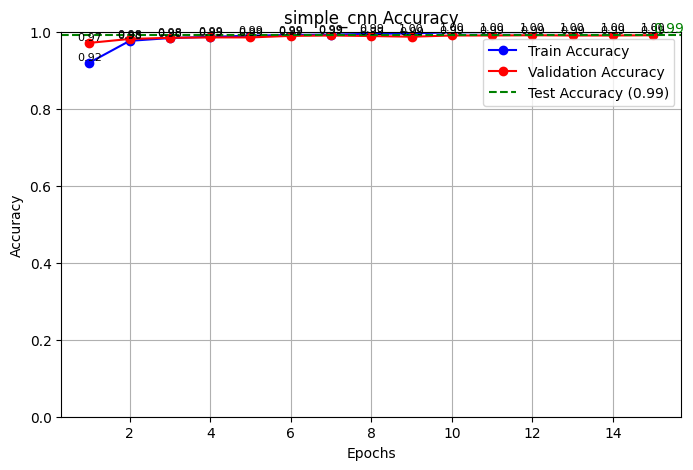

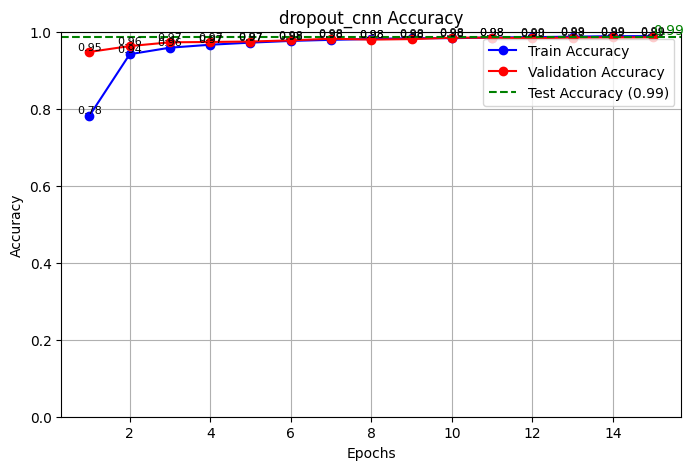

In [10]:
# ===========================
# 6) Compare Models and Plot
# ===========================
comparison_data = []

for r in results:
    history = r["history"].history
    train_acc = history["accuracy"][-1]
    train_loss = history["loss"][-1]
    val_acc = history["val_accuracy"][-1]
    val_loss = history["val_loss"][-1]
    test_acc = r["test_accuracy"]
    test_loss = r["test_loss"]

    comparison_data.append({
        "Model": r["model"],
        "Train Accuracy": train_acc,
        "Train Loss": train_loss,
        "Val Accuracy": val_acc,
        "Val Loss": val_loss,
        "Test Accuracy": test_acc,
        "Test Loss": test_loss
    })

df_full_results = pd.DataFrame(comparison_data)
print("\nModel Metrics Comparison:")
print(df_full_results)

# ===========================
# Plot train, val, and test accuracy with datapoint values
# ===========================
for r in results:
    history = r["history"].history
    epochs = range(1, len(history["accuracy"]) + 1)
    test_acc = r["test_accuracy"]

    plt.figure(figsize=(8,5))

    # Train Accuracy
    plt.plot(epochs, history["accuracy"], 'bo-', label="Train Accuracy")
    for x, y in zip(epochs, history["accuracy"]):
        plt.text(x, y, f"{y:.2f}", fontsize=8, ha='center', va='bottom')

    # Validation Accuracy
    plt.plot(epochs, history["val_accuracy"], 'ro-', label="Validation Accuracy")
    for x, y in zip(epochs, history["val_accuracy"]):
        plt.text(x, y, f"{y:.2f}", fontsize=8, ha='center', va='bottom')

    # Test Accuracy as horizontal line
    plt.axhline(y=test_acc, color='g', linestyle='--', label=f"Test Accuracy ({test_acc:.2f})")
    plt.text(epochs[-1], test_acc, f"{test_acc:.2f}", color='g', fontsize=10, ha='left', va='bottom')

    plt.title(f"{r['model']} Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.ylim(0, 1)
    plt.legend()
    plt.grid(True)
    plt.show()
